In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
data = pd.read_csv("./data/ecommerce.csv")
data
data2 = pd.read_csv("./data/ecommerce.csv")
data2

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...,...,...,...
495,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872\nLake Jamiefurt,...",Tan,33.237660,13.566160,36.417985,3.746573,573.847438
496,katrina56@gmail.com,"172 Owen Divide Suite 497\nWest Richard, CA 19320",PaleVioletRed,34.702529,11.695736,37.190268,3.576526,529.049004
497,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633\nSouth Chadburgh, ...",Cornsilk,32.646777,11.499409,38.332576,4.958264,551.620145
498,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808\nBrendachester, TX...",Teal,33.322501,12.391423,36.840086,2.336485,456.469510


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [12]:
outlier = data.describe()
outlier

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
data.columns[3:]

Index(['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [ ]:
sns.boxplot(data[])

In [9]:
outlier.loc['75%'] + (1.5*(outlier.loc['75%'] - outlier.loc['25%']))

Avg. Session Length      35.767230
Time on App              14.802394
Time on Website          39.767195
Length of Membership      5.920580
Yearly Amount Spent     705.727153
dtype: float64

In [11]:
outlier.loc['25%'] - (1.5*(outlier.loc['75%'] - outlier.loc['25%']))

Avg. Session Length      30.286577
Time on App               9.339609
Time on Website          34.298495
Length of Membership      1.136371
Yearly Amount Spent     288.624951
dtype: float64

In [13]:
data['Address'].nunique()

500

In [38]:
data['state_name'] = data2['Address'].str.split(",").apply(lambda x: x[-1].split()[-2])

In [39]:
data.groupby('state_name')['Yearly Amount Spent'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
state_name,,,,,,,,
PW,6.0,413.315738,41.089085,347.776927,400.548738,409.858739,442.239989,461.920877
GU,6.0,414.701360,100.849577,304.135592,342.417144,397.705547,469.328461,571.471034
NH,7.0,448.609303,68.641665,352.550108,402.141196,461.790959,499.879045,521.883573
NV,6.0,452.483974,84.186395,298.762008,439.175327,468.934705,497.186987,542.412477
LA,6.0,461.629503,77.256200,368.654785,406.529416,464.109429,493.333888,582.491924
...,...,...,...,...,...,...,...,...
MN,11.0,546.266279,81.288184,401.033135,485.806863,583.977802,610.497563,637.102448
AR,6.0,550.633210,28.390539,517.165136,527.858082,553.068623,565.213072,591.781089
IN,7.0,558.303399,122.284826,462.897636,470.345119,488.786061,625.115698,765.518462


선형성, 독립성, 등분산성, 정규성

In [40]:
data

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,state_name
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054,MI
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933,CA
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505,DC
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344,OH
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092,PR
...,...,...,...,...,...,...,...,...,...
495,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872\nLake Jamiefurt,...",Tan,33.237660,13.566160,36.417985,3.746573,573.847438,UT
496,katrina56@gmail.com,"172 Owen Divide Suite 497\nWest Richard, CA 19320",PaleVioletRed,34.702529,11.695736,37.190268,3.576526,529.049004,CA
497,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633\nSouth Chadburgh, ...",Cornsilk,32.646777,11.499409,38.332576,4.958264,551.620145,TN
498,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808\nBrendachester, TX...",Teal,33.322501,12.391423,36.840086,2.336485,456.469510,TX


In [26]:
data.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [14]:
data['Avatar'].nunique()

138

In [27]:
data.corr(numeric_only=True)

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg. Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


<Axes: >

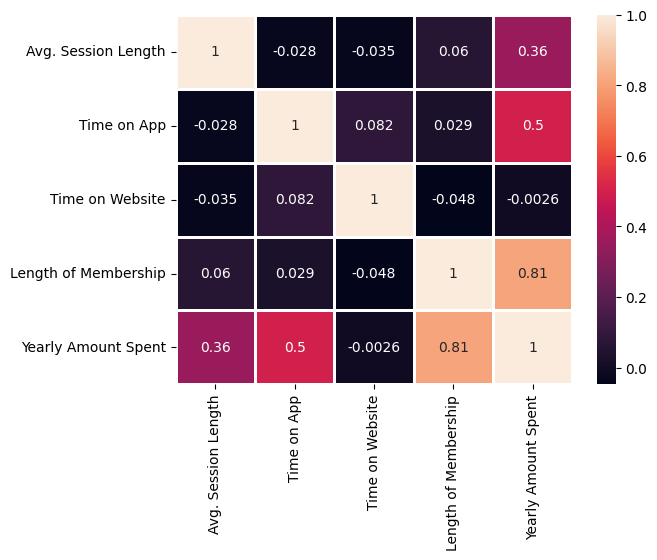

In [28]:
sns.heatmap(data.corr(numeric_only=True), annot=True, linewidth=1)

In [41]:
data = data.drop(['Email', 'Address', 'Avatar'], axis=1)
data.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,state_name
0,34.497268,12.655651,39.577668,4.082621,587.951054,MI
1,31.926272,11.109461,37.268959,2.664034,392.204933,CA
2,33.000915,11.330278,37.110597,4.104543,487.547505,DC
3,34.305557,13.717514,36.721283,3.120179,581.852344,OH
4,33.330673,12.795189,37.536653,4.446308,599.406092,PR


In [55]:
data.columns = [col.replace(" ", "").replace(".", "") for col in data.columns]
data.head()

,AvgSessionLength,TimeonApp,TimeonWebsite,LengthofMembership,YearlyAmountSpent,state_name
0,34.497268,12.655651,39.577668,4.082621,587.951054,MI
1,31.926272,11.109461,37.268959,2.664034,392.204933,CA
2,33.000915,11.330278,37.110597,4.104543,487.547505,DC
3,34.305557,13.717514,36.721283,3.120179,581.852344,OH
4,33.330673,12.795189,37.536653,4.446308,599.406092,PR


In [56]:
X = data.drop('YearlyAmountSpent', axis=1)
y = data['YearlyAmountSpent']

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

다중선형회귀분석하기

In [59]:
from statsmodels.formula.api import ols

In [60]:
train_data = pd.concat([X_train, y_train], axis=1)
train_data.head()

,AvgSessionLength,TimeonApp,TimeonWebsite,LengthofMembership,state_name,YearlyAmountSpent
342,32.342796,11.409645,35.777782,3.872432,MT,486.083426
359,32.054262,13.149670,37.650400,4.195614,ME,561.874658
109,33.356874,13.452129,38.503009,3.318822,MP,549.008227
50,33.256335,13.858062,37.780265,5.976768,UT,725.584814
452,33.552108,11.120871,36.808376,4.027814,ME,521.195311


In [61]:
train_data.columns

Index(['AvgSessionLength', 'TimeonApp', 'TimeonWebsite', 'LengthofMembership',
       'state_name', 'YearlyAmountSpent'],
      dtype='object')

In [62]:
lm = ols('YearlyAmountSpent ~ AvgSessionLength + TimeonApp + TimeonWebsite + LengthofMembership + state_name', data=train_data).fit()

In [63]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      YearlyAmountSpent   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     389.1
Date:                Thu, 29 Aug 2024   Prob (F-statistic):          4.36e-279
Time:                        15:15:41   Log-Likelihood:                -1449.5
No. Observations:                 400   AIC:                             3031.
Df Residuals:                     334   BIC:                             3294.
Df Model:                          65                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept          -1044.0261     27.310    -38.228      0.000   -1097.748    -990.304
state_name[T.AE]      -0.2681      3.692     -0.073      0.942      -7.531       6.995
state_name[T.AK]       0.6355      5.219      0.122      0.903      -9.631      10.902
state_name[T.AL]      -1.4055      4.423     -0.318      0.751     -10.106       7.295
state_name[T.AP]      -2.0814      4.127     -0.504      0.614     -10.200       6.037
state_name[T.AR]      11.2649      5.701      1.976      0.049       0.050      22.480
state_name[T.AS]      -2.9825      4.620     -0.646      0.519     -12.070       6.105
state_name[T.AZ]      -3.4977      4.606     -0.759      0.448     -12.558       5.563
state_name[T.CA]       3.2973      5.208      0.633      0.527      -6.948      13.543
state_name[T.CO]       4.3226      5.638      0.767      0.444      -6.768      15.413
state_name[T.CT]      -1.8944      5.675     -0.334      0.739     -13.058       9.269
state_name[T.DC]      -7.1931      5.631     -1.277      0.202     -18.270       3.883
state_name[T.DE]      -2.2724      4.125     -0.551      0.582     -10.388       5.843
state_name[T.FL]      -1.0106      4.409     -0.229      0.819      -9.683       7.662
state_name[T.FM]       1.5194      4.858      0.313      0.755      -8.037      11.076
state_name[T.GA]       6.3291      4.620      1.370      0.172      -2.759      15.417
state_name[T.GU]      -1.2212      5.663     -0.216      0.829     -12.361       9.919
state_name[T.HI]      -3.0376      4.846     -0.627      0.531     -12.571       6.496
state_name[T.IA]       5.8753      4.876      1.205      0.229      -3.717      15.467
state_name[T.ID]      -7.0579     10.301     -0.685      0.494     -27.322      13.206
state_name[T.IL]       2.5970      4.850      0.535      0.593      -6.943      12.137
state_name[T.IN]       1.6246      4.883      0.333      0.740      -7.980      11.229
state_name[T.KS]       3.4717      4.408      0.788      0.432      -5.200      12.143
state_name[T.KY]      -1.9248      4.405     -0.437      0.662     -10.590       6.741
state_name[T.LA]       0.3371      4.863      0.069      0.945      -9.229       9.903
state_name[T.MA]       0.3770      5.188      0.073      0.942      -9.829      10.583
state_name[T.MD]       7.5277      5.182      1.453      0.147      -2.666      17.721
state_name[T.ME]       3.6069      4.625      0.780      0.436      -5.490      12.704
state_name[T.MH]      -0.7961      4.876     -0.163      0.870     -10.387       8.795
state_name[T.MI]       9.6009      4.401      2.181      0.030       0.943      18.258
state_name[T.MN]       0.8870      4.911      0.181      0.857      -8.773      10.547
state_name[T.MO]       5.8362      4.023      1.451      0.148      -2.077      13.750
state_name[T.MP]       6.4842      5.6

In [64]:
import statsmodels.api as sm

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [65]:
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [76]:
lr = sm.OLS(y2_train, X2_train).fit()

In [77]:
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      YearlyAmountSpent   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     389.1
Date:                Thu, 29 Aug 2024   Prob (F-statistic):          4.36e-279
Time:                        15:38:50   Log-Likelihood:                -1449.5
No. Observations:                 400   AIC:                             3031.
Df Residuals:                     334   BIC:                             3294.
Df Model:                          65                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -1026.3913     26.613    -38.567      0.000   -1078.741    -974.041
AvgSessionLength      25.4119      0.541     46.946      0.000      24.347      26.477
TimeonApp             38.5121      0.541     71.238      0.000      37.449      39.576
TimeonWebsite          0.5356      0.531      1.009      0.314      -0.508       1.579
LengthofMembership    61.7833      0.542    114.036      0.000      60.718      62.849
state_name_AA        -17.6348      2.730     -6.460      0.000     -23.005     -12.265
state_name_AE        -17.9029      2.626     -6.818      0.000     -23.068     -12.738
state_name_AK        -16.9992      4.465     -3.807      0.000     -25.783      -8.216
state_name_AL        -19.0403      3.540     -5.379      0.000     -26.003     -12.077
state_name_AP        -19.7162      3.175     -6.210      0.000     -25.961     -13.471
state_name_AR         -6.3699      4.983     -1.278      0.202     -16.173       3.433
state_name_AS        -20.6173      3.787     -5.444      0.000     -28.068     -13.167
state_name_AZ        -21.1325      3.766     -5.612      0.000     -28.540     -13.725
state_name_CA        -14.3375      4.449     -3.223      0.001     -23.088      -5.587
state_name_CO        -13.3122      4.925     -2.703      0.007     -23.001      -3.624
state_name_CT        -19.5292      4.928     -3.963      0.000     -29.223      -9.836
state_name_DC        -24.8279      4.937     -5.029      0.000     -34.539     -15.116
state_name_DE        -19.9071      3.168     -6.284      0.000     -26.139     -13.676
state_name_FL        -18.6454      3.560     -5.238      0.000     -25.648     -11.643
state_name_FM        -16.1153      4.106     -3.925      0.000     -24.193      -8.038
state_name_GA        -11.3057      3.773     -2.997      0.003     -18.727      -3.884
state_name_GU        -18.8560      4.959     -3.802      0.000     -28.610      -9.101
state_name_HI        -20.6723      4.065     -5.086      0.000     -28.668     -12.677
state_name_IA        -11.7595      4.062     -2.895      0.004     -19.750      -3.769
state_name_ID        -24.6927      9.792     -2.522      0.012     -43.955      -5.430
state_name_IL        -15.0378      4.079     -3.687      0.000     -23.061      -7.014
state_name_IN        -16.0102      4.072     -3.932      0.000     -24.020      -8.001
state_name_KS        -14.1631      3.509     -4.036      0.000     -21.066      -7.260
state_name_KY        -19.5596      3.550     -5.510      0.000     -26.543     -12.576
state_name_LA        -17.2977      4.044     -4.277      0.000     -25.253      -9.342
state_name_MA        -17.2578      4.404     -3.919      0.000     -25.920      -8.595
state_name_MD        -10.1071      4.428     -2.283      0.023     -18.817      -1.398
state_name_ME        -14.0279      3.7

In [81]:
pred = lm.predict(X_test)

PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Number of rows mismatch between data argument and state_name (100 versus 500)
    YearlyAmountSpent ~ AvgSessionLength + TimeonApp + TimeonWebsite + LengthofMembership + state_name
                                                                                            ^^^^^^^^^^

In [79]:
from sklearn.metrics import mean_squared_error

In [80]:
print("Mean_Squared_Error(MSE): ", mean_squared_error(y_test, pred))
print("Root_Mean_Squared_Error(RMSE): ", np.sqrt(mean_squared_error(y_test, pred)))

NameError: name 'pred' is not defined

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=pred, label='data_points')
sns.redplot(x=y_test, y=pred, scatter=False, label="Regression Line", color='red')
plt.xlabel("Actual Yearly Amount Spent")

In [70]:
X_train.head(2)

,const,AvgSessionLength,TimeonApp,TimeonWebsite,LengthofMembership,state_name
342,1.0,32.342796,11.409645,35.777782,3.872432,MT
359,1.0,32.054262,13.149670,37.650400,4.195614,ME


In [71]:
X_train = pd.get_dummies(X_train)
X_test =  pd.get_dummies(X_test)

In [73]:
X_train = X_train.astype('float')
X_test = X_test.astype('float')

In [72]:
X_train.apply(pd.to_numeric)

,const,AvgSessionLength,TimeonApp,TimeonWebsite,LengthofMembership,state_name_AA,state_name_AE,state_name_AK,state_name_AL,state_name_AP,...,state_name_TN,state_name_TX,state_name_UT,state_name_VA,state_name_VI,state_name_VT,state_name_WA,state_name_WI,state_name_WV,state_name_WY
342,1.0,32.342796,11.409645,35.777782,3.872432,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
359,1.0,32.054262,13.149670,37.650400,4.195614,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
109,1.0,33.356874,13.452129,38.503009,3.318822,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
50,1.0,33.256335,13.858062,37.780265,5.976768,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
452,1.0,33.552108,11.120871,36.808376,4.027814,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,1.0,34.081646,12.104542,36.059646,3.974522,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
67,1.0,32.805220,11.835476,36.375066,3.439591,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
25,1.0,33.029332,11.765813,37.738525,2.721736,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
196,1.0,32.733224,11.818572,37.102031,1.503854,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
sorted(data.groupby('Avatar')['Yearly Amount Spent'].mean())

[386.6479469644702,
 406.72210505413426,
 419.63294156751954,
 420.4525495603057,
 425.7450920310528,
 426.2491997948072,
 430.6901723817928,
 432.5880745084584,
 434.0216997527185,
 435.50696136042393,
 435.53438736846255,
 436.7205558562188,
 436.93721042160973,
 437.98836007828095,
 441.0606890984435,
 444.79794926582264,
 449.6439355046467,
 450.8085408678162,
 452.62725499508304,
 457.3757575535788,
 457.84769594494855,
 458.1109670290833,
 459.73175574914313,
 460.6932386153623,
 464.4492715811856,
 464.64799776409825,
 465.219163427335,
 465.94376701872335,
 467.9852374676245,
 469.89882388155974,
 471.9477147236624,
 472.1404800783187,
 473.33094790940635,
 473.62637580373496,
 474.3145305571195,
 475.2178389767011,
 475.759067788328,
 476.3801445434332,
 476.7667241547634,
 476.989533966875,
 477.9051175131702,
 478.33616628747586,
 480.6720732687792,
 481.0113949279279,
 481.3977129840615,
 482.5055820949065,
 483.3034620257754,
 483.40727367591916,
 483.5028225299293,
 483.5